In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [26]:
# Load data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))
OE_Activity_prepped = pd.read_parquet(Path("../data/processed/oe_activity_prepped.parquet"))
OE_joined = pd.read_parquet(Path("../data/processed/oe_joined.parquet"))    
product_pick_times = pd.read_csv(Path("../data/processed/product_pick_times.csv"))

# Rename Travel_Distance column to Distance for df OE_detailed
OE_detailed = OE_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [27]:
display(OE_detailed.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0


In [28]:
print("Percentage of rows with Time_Delta_sec < 600:", (OE_detailed["Time_Delta_sec"] < 600).mean())
print("Percentage of rows with Time_Delta_sec < 300:", (OE_detailed["Time_Delta_sec"] < 300).mean())
print("Percentage of rows with Time_Delta_sec < 180:", (OE_detailed["Time_Delta_sec"] < 180).mean())
print("Percentage of rows with Time_Delta_sec < 150:", (OE_detailed["Time_Delta_sec"] < 150).mean())
print("Percentage of rows with Time_Delta_sec < 120:", (OE_detailed["Time_Delta_sec"] < 120).mean())

Percentage of rows with Time_Delta_sec < 600: 0.9827546026567233
Percentage of rows with Time_Delta_sec < 300: 0.9618969937077604
Percentage of rows with Time_Delta_sec < 180: 0.9314315374674266
Percentage of rows with Time_Delta_sec < 150: 0.914196733120061
Percentage of rows with Time_Delta_sec < 120: 0.885457935213237


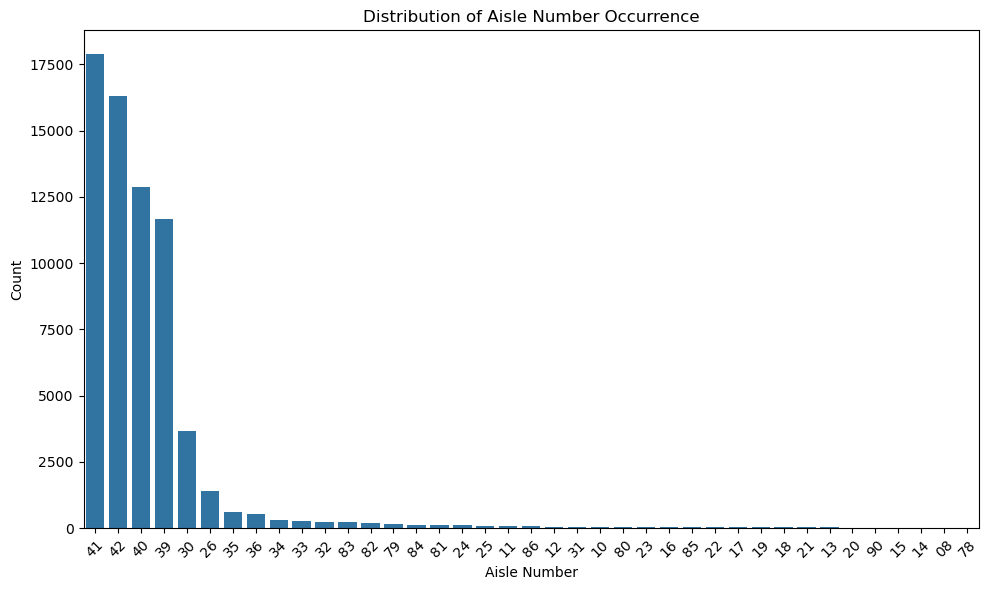

In [29]:
# Plot Distribution of aisle number occurrance, filter by "WorkCode" == "30"
plt.figure(figsize=(10, 6))
sns.countplot(data=OE_detailed[OE_detailed["WorkCode"] == "30"], x='Aisle', order=OE_detailed[OE_detailed["WorkCode"] == "30"]['Aisle'].value_counts().index)
plt.title('Distribution of Aisle Number Occurrence')
plt.xlabel('Aisle Number')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# OE WC30
aisle_counts = OE_detailed[OE_detailed["WorkCode"] == "30"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))
# OE WC20
aisle_counts = OE_detailed[OE_detailed["WorkCode"] == "20"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))
# # OE WC10
aisle_counts = OE_detailed[OE_detailed["WorkCode"] == "10"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))

  Aisle  Percentage
0    41    0.264276
1    42    0.240636
2    40    0.190181
3    39    0.172451
4    30    0.054430
5    26    0.020892
6    35    0.008968
7    36    0.007904
  Aisle  Percentage
0    25    0.254551
1    24    0.185169
2    23    0.069739
3    10    0.052650
4    14    0.039666
5    19    0.038283
6    15    0.037748
7    12    0.037034
  Aisle  Percentage
0    36    0.110930
1    35    0.106512
2    33    0.068605
3    32    0.064884
4    34    0.060233
5    18    0.039302
6    21    0.039070
7    25    0.037907


In [31]:
# Load OF data, similarly to OE
OF_detailed = pd.read_parquet(Path("../data/processed/of_detailed.parquet"))
OF_detailed = OF_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [32]:
# OF WC30
aisle_counts = OF_detailed[OF_detailed["WorkCode"] == "30"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))
# OF WC20
aisle_counts = OF_detailed[OF_detailed["WorkCode"] == "20"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))
# OF WC10
aisle_counts = OF_detailed[OF_detailed["WorkCode"] == "10"]["Aisle"].value_counts(normalize=True).reset_index()
aisle_counts.columns = ["Aisle", "Percentage"]
print(aisle_counts.head(8))

  Aisle  Percentage
0    70    0.199124
1    71    0.159582
2    74    0.143969
3    73    0.135793
4    75    0.093691
5    72    0.091819
6    64    0.037262
7    29    0.011169
  Aisle  Percentage
0    29    0.361189
1    30    0.084673
2    21    0.065139
3    20    0.054866
4    22    0.042877
5    27    0.039892
6    26    0.033404
7    28    0.025929
  Aisle  Percentage
0    44    0.065146
1    22    0.064953
2    20    0.055287
3    27    0.055287
4    39    0.054707
5    43    0.051807
6    42    0.046588
7    40    0.043495


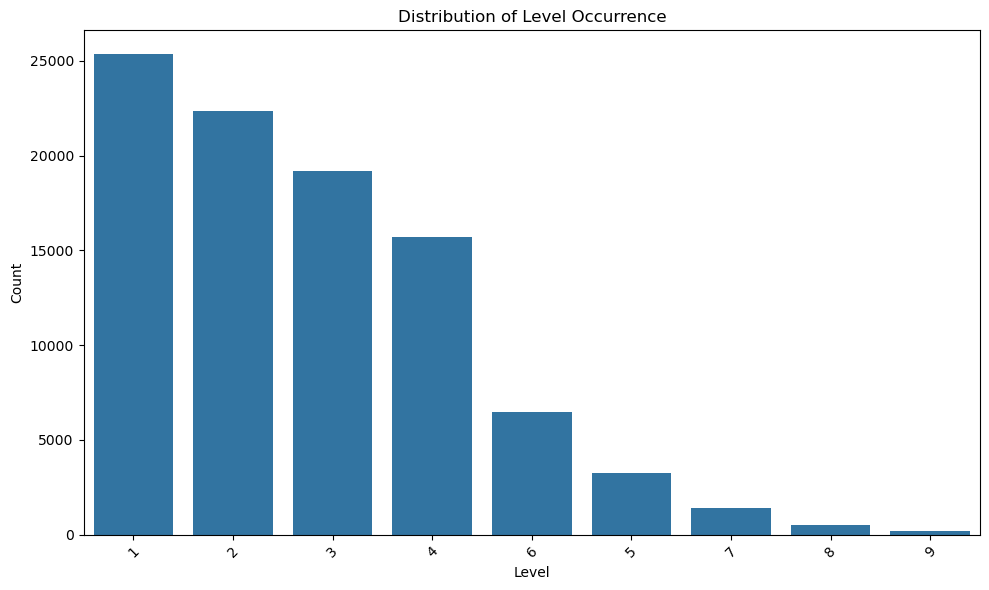

In [33]:
# Distribution of level
plt.figure(figsize=(10, 6))
sns.countplot(data=OE_detailed, x='Level', order=OE_detailed['Level'].value_counts().index)
plt.title('Distribution of Level Occurrence')
plt.xlabel('Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unique UnitOfMeasure values: ['PK' 'EA' 'BX' 'RO' 'PR' 'BG' 'SL' 'RL' 'CA' 'CT' 'CS' 'KT' 'TR' 'DI'
 'OP' 'VI' 'SP' 'PC' None 'CN' 'DZ' 'TB' 'GR' 'BT' 'ST' 'SH' 'PD' 'GA'
 'EN' 'TY' 'JR']


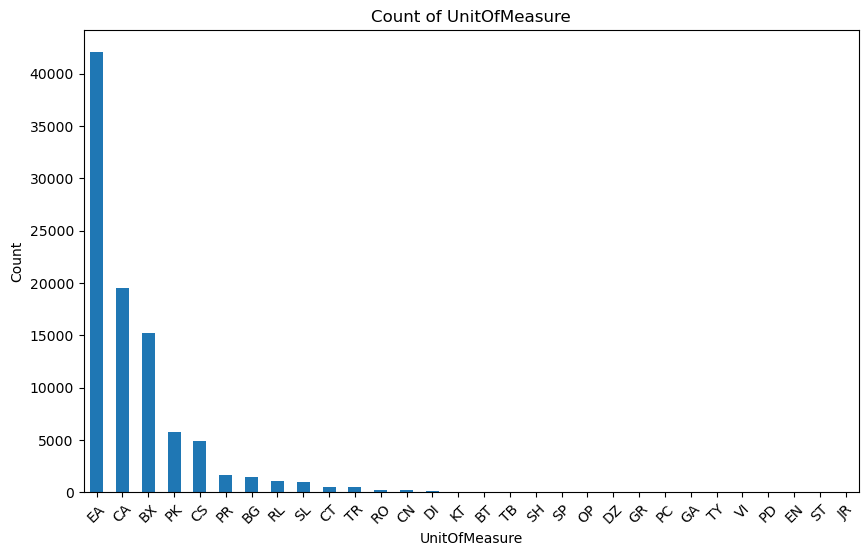

In [34]:
# print different unitof measures in df
print("Unique UnitOfMeasure values:", OE_detailed["UnitOfMeasure"].unique())
# barplot showing count
plt.figure(figsize=(10, 6))
OE_detailed["UnitOfMeasure"].value_counts().plot(kind="bar")
plt.title("Count of UnitOfMeasure")
plt.xlabel("UnitOfMeasure")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [35]:
# Count percentage of product occurring more than 10, 20, 30 times
product_counts = OE_detailed['ProductID'].value_counts()
print("Percentage of products occurring more than 10 times:", (product_counts > 10).mean())
print("Percentage of products occurring more than 20 times:", (product_counts > 20).mean())
print("Percentage of products occurring more than 30 times:", (product_counts > 30).mean())
# how much of the data is covered by products occurring more than 10, 20, 30 times
print("Percentage of data covered by products occurring more than 10 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 10].index)).mean())
print("Percentage of data covered by products occurring more than 20 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 20].index)).mean())
print("Percentage of data covered by products occurring more than 30 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 30].index)).mean())

Percentage of products occurring more than 10 times: 0.2103434451423226
Percentage of products occurring more than 20 times: 0.1274889750100227
Percentage of products occurring more than 30 times: 0.09007082720833891
Percentage of data covered by products occurring more than 10 times: 0.8184466430795958
Percentage of data covered by products occurring more than 20 times: 0.7208851507383318
Percentage of data covered by products occurring more than 30 times: 0.6475604330416729


In [36]:
# Percentage of total rows that are in the top 100 most common products
top_100_products = product_counts.head(100).index
percentage_top_100 = (OE_detailed['ProductID'].isin(top_100_products)).mean()
print("Percentage of data covered by top 100 most common products:", percentage_top_100)

Percentage of data covered by top 100 most common products: 0.27546026567233745


In [37]:
# Also load OE_activity, OF_activity, and RT_activity, and RT_activity2, check distinct number of days in each
print("OE_activity distinct days:", OE_Activity_prepped["Timestamp"].dt.date.nunique())
print("OF_activity distinct days:", pd.read_parquet(Path("../data/processed/of_activity_prepped.parquet"))["Timestamp"].dt.date.nunique())
print("RT_activity distinct days:", pd.read_parquet(Path("../data/processed/rt_activity_prepped.parquet"))["Timestamp"].dt.date.nunique())
print("RT_activity2 distinct days:", pd.read_parquet(Path("../data/processed/rt_activity2_prepped.parquet"))["Timestamp"].dt.date.nunique())

# compare number of rows for OE_detailed, OF_detailed
print("OE_detailed number of rows:", OE_detailed.shape[0])
print("OF_detailed number of rows:", OF_detailed.shape[0])

OE_activity distinct days: 8
OF_activity distinct days: 12
RT_activity distinct days: 13
RT_activity2 distinct days: 621
OE_detailed number of rows: 94402
OF_detailed number of rows: 126237


In [ ]:
results_table = pd.DataFrame({
    "Warehouse": ["OE", "OF"],
    "Time_Delta_sec < 600": [(OE_detailed["Time_Delta_sec"] < 600).mean(), (OF_detailed["Time_Delta_sec"] < 600).mean()],
    "Time_Delta_sec < 300": [(OE_detailed["Time_Delta_sec"] < 300).mean(), (OF_detailed["Time_Delta_sec"] < 300).mean()],
    "Time_Delta_sec < 180": [(OE_detailed["Time_Delta_sec"] < 180).mean(), (OF_detailed["Time_Delta_sec"] < 180).mean()],
    "Time_Delta_sec < 150": [(OE_detailed["Time_Delta_sec"] < 150).mean(), (OF_detailed["Time_Delta_sec"] < 150).mean()],
    "Time_Delta_sec < 120": [(OE_detailed["Time_Delta_sec"] < 120).mean(), (OF_detailed["Time_Delta_sec"] < 120).mean()]
})
display(results_table)

,Warehouse,Time_Delta_sec < 600,Time_Delta_sec < 300,Time_Delta_sec < 180,Time_Delta_sec < 150,Time_Delta_sec < 120
0,OE,0.982755,0.961897,0.931432,0.914197,0.885458
1,OF,0.981962,0.961596,0.922447,0.896330,0.852967


In [43]:
# distinct workcodes in OF
print("Distinct WorkCodes in OF:", OF_detailed["WorkCode"].unique())
# number of rows with each WC
print("Number of rows with each WorkCode in OF:")
print(OF_detailed["WorkCode"].value_counts())
# Percentage of distance >= 0
print("Percentage of rows with Distance >= 0 in OF:", (OF_detailed["Distance"] >= 0).mean())
# percentage with timestamp is not null
print("Percentage of rows with non-null Timestamp in OF:", OF_detailed["Timestamp"].notnull().mean())

Distinct WorkCodes in OF: ['20' '30' '10']
Number of rows with each WorkCode in OF:
WorkCode
30    78524
20    42540
10     5173
Name: count, dtype: int64
Percentage of rows with Distance >= 0 in OF: 0.9878799401126452
Percentage of rows with non-null Timestamp in OF: 1.0


In [44]:
# OE detailed col names
print("OE_detailed columns:", OE_detailed.columns.tolist())

OE_detailed columns: ['ActivityCode', 'UserID', 'WorkCode', 'AssignmentID', 'ProductID', 'Quantity', 'Timestamp', 'LocationID', 'Prev_Timestamp', 'Prev_LocationID', 'Time_Delta_sec', 'ProductCode', 'UnitOfMeasure', 'Weight', 'Cube', 'Aisle', 'Bay', 'Level', 'Slot', 'Prev_Aisle', 'Prev_Bay', 'Prev_Level', 'Prev_Slot', 'Aisle2', 'Bay2', 'Prev_Aisle2', 'Prev_Bay2', 'LocKey', 'PrevLocKey', 'Distance']
